# 04 Chunking Experiments

## Goal

This notebook turns SEC 10-K sections into smaller RAG-ready chunks.

The workflow is:

```text
RAG-ready SEC sections
→ clean section text
→ test chunking strategies
→ compare chunk counts
→ choose final chunk size
→ save RAG-ready chunk dataset
```

Chunking matters because retrieval quality depends heavily on how the text is split.

If chunks are too small, they lose context.

If chunks are too large, they become noisy.

For the first version of this project, we will use simple word-based chunking because it is easy to understand, easy to explain, and good enough for a strong first RAG system.

In [1]:
# Import tools for file and folder paths
from pathlib import Path

# Import pandas for working with tables
import pandas as pd

# Import regular expressions for text cleaning
import re

# Import matplotlib for simple charts
import matplotlib.pyplot as plt

In [2]:
# Detect the project root automatically
# If this notebook is inside the notebooks folder, move one level up
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Create main data paths
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

# Create a folder for chunking outputs
CHUNK_DIR = PROCESSED_DIR / "sec_chunks"
CHUNK_DIR.mkdir(parents=True, exist_ok=True)

# Print paths to confirm everything is pointing to the right place
print("Project root:", PROJECT_ROOT)
print("Processed data folder:", PROCESSED_DIR)
print("Chunk output folder:", CHUNK_DIR)

Project root: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI
Processed data folder: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\processed
Chunk output folder: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\processed\sec_chunks


In [3]:
# Set path to the RAG-ready section dataset from notebook 03
rag_sections_file = PROCESSED_DIR / "sec_10k_rag_sections.csv"

# Check that the file exists before loading it
if not rag_sections_file.exists():
    raise FileNotFoundError(
        f"Could not find {rag_sections_file}. Run 03_section_extraction.ipynb first."
    )

# Load the section-level RAG dataset
rag_sections_df = pd.read_csv(rag_sections_file)

# Preview the dataset
rag_sections_df.head()

,document_id,ticker,company_name,filing_date,accession_number,filing_url,section_name,source_label,text,character_count,word_count
0,AAPL_2025-10-31_item_1_business,AAPL,Apple,2025-10-31,0000320193-25-000079,https://www.sec.gov/Archives/edgar/data/320193...,item_1_business,AAPL 2025-10-31 10-K item_1_business,Item 1. Business Company Background The Compan...,16050,2380
1,AAPL_2025-10-31_item_1a_risk_factors,AAPL,Apple,2025-10-31,0000320193-25-000079,https://www.sec.gov/Archives/edgar/data/320193...,item_1a_risk_factors,AAPL 2025-10-31 10-K item_1a_risk_factors,Item 1A. Risk Factors The following summarizes...,68044,9784
2,AAPL_2025-10-31_item_7_mda,AAPL,Apple,2025-10-31,0000320193-25-000079,https://www.sec.gov/Archives/edgar/data/320193...,item_7_mda,AAPL 2025-10-31 10-K item_7_mda,Item 7 of this Form 10-K under the heading “Ma...,18710,2773
3,AAPL_2025-10-31_item_7a_market_risk,AAPL,Apple,2025-10-31,0000320193-25-000079,https://www.sec.gov/Archives/edgar/data/320193...,item_7a_market_risk,AAPL 2025-10-31 10-K item_7a_market_risk,Item 7A. Quantitative and Qualitative Disclosu...,3020,460
4,AMD_2026-02-04_item_1_business,AMD,Advanced Micro Devices,2026-02-04,0000002488-26-000018,https://www.sec.gov/Archives/edgar/data/2488/0...,item_1_business,AMD 2026-02-04 10-K item_1_business,ITEM 1. BUSINESS Cautionary Statement Regardin...,3275,468


In [4]:
# Count the number of section records
num_sections = len(rag_sections_df)

# Count the number of unique companies
num_companies = rag_sections_df["ticker"].nunique()

# Count the number of section types
num_section_types = rag_sections_df["section_name"].nunique()

# Print a simple dataset summary
print("Number of section records:", num_sections)
print("Number of companies:", num_companies)
print("Number of section types:", num_section_types)

# Show how many records exist for each section type
rag_sections_df["section_name"].value_counts()

Number of section records: 20
Number of companies: 5
Number of section types: 4


section_name
item_1_business         5
item_1a_risk_factors    5
item_7_mda              5
item_7a_market_risk     5
Name: count, dtype: int64

#### check required columns

In [5]:
# Define the columns needed for chunking and citation metadata
required_columns = [
    "document_id",
    "ticker",
    "company_name",
    "filing_date",
    "accession_number",
    "section_name",
    "source_label",
    "text",
    "character_count",
    "word_count"
]

# Check which required columns are missing
missing_columns = [
    column for column in required_columns
    if column not in rag_sections_df.columns
]

# Stop the notebook if important columns are missing
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Confirm that the required columns exist
print("All required columns are present.")

All required columns are present.


In [6]:
# Some earlier versions of notebook 03 may not include filing_url
# This keeps notebook 04 from breaking if that column is missing
if "filing_url" not in rag_sections_df.columns:
    rag_sections_df["filing_url"] = None

# Preview citation-related columns
rag_sections_df[
    [
        "ticker",
        "section_name",
        "source_label",
        "filing_url"
    ]
].head()

,ticker,section_name,source_label,filing_url
0,AAPL,item_1_business,AAPL 2025-10-31 10-K item_1_business,https://www.sec.gov/Archives/edgar/data/320193...
1,AAPL,item_1a_risk_factors,AAPL 2025-10-31 10-K item_1a_risk_factors,https://www.sec.gov/Archives/edgar/data/320193...
2,AAPL,item_7_mda,AAPL 2025-10-31 10-K item_7_mda,https://www.sec.gov/Archives/edgar/data/320193...
3,AAPL,item_7a_market_risk,AAPL 2025-10-31 10-K item_7a_market_risk,https://www.sec.gov/Archives/edgar/data/320193...
4,AMD,item_1_business,AMD 2026-02-04 10-K item_1_business,https://www.sec.gov/Archives/edgar/data/2488/0...


## Chunking Strategy

We will use word-based chunking.

The process is:

```text
section text
→ clean text
→ split into words
→ create fixed-size chunks
→ use overlap between chunks
→ attach metadata
```

We will test three settings:

```text
250 words with 50 overlap
350 words with 75 overlap
500 words with 100 overlap
```

The final first-version choice will be:

```text
350 words with 75 overlap
```

This is a good starting point because it keeps enough context while still creating focused searchable chunks.

In [7]:
def clean_chunk_text(text):
    """
    Clean section text before chunking.
    """

    # Handle missing text values
    if pd.isna(text):
        return ""

    # Convert text to string
    text = str(text)

    # Replace repeated whitespace with one space
    text = re.sub(r"\s+", " ", text)

    # Remove leading and trailing whitespace
    text = text.strip()

    # Return clean text
    return text

In [8]:
def create_word_chunks(text, chunk_size=350, chunk_overlap=75):
    """
    Split text into overlapping word chunks.

    Example:
    chunk_size = 350
    chunk_overlap = 75

    Chunk 1: words 0 to 350
    Chunk 2: words 275 to 625
    Chunk 3: words 550 to 900
    """

    # Clean the text first
    text = clean_chunk_text(text)

    # Split the text into words
    words = text.split()

    # Create an empty list for chunk records
    chunks = []

    # Return no chunks if the text is empty
    if len(words) == 0:
        return chunks

    # Calculate how far to move for each new chunk
    step_size = chunk_size - chunk_overlap

    # Stop if overlap is too large
    if step_size <= 0:
        raise ValueError("chunk_overlap must be smaller than chunk_size.")

    # Start from the first word
    start_word = 0

    # Keep chunking until the end of the word list
    while start_word < len(words):

        # Calculate the ending word index
        end_word = start_word + chunk_size

        # Select the words for this chunk
        chunk_words = words[start_word:end_word]

        # Join the words back into text
        chunk_text = " ".join(chunk_words)

        # Store chunk details
        chunks.append({
            "chunk_text": chunk_text,
            "start_word": start_word,
            "end_word": min(end_word, len(words)),
            "chunk_word_count": len(chunk_words),
            "chunk_character_count": len(chunk_text)
        })

        # Stop if this chunk reached the end of the section
        if end_word >= len(words):
            break

        # Move forward by the step size
        start_word += step_size

    # Return all chunks
    return chunks

In [9]:
# Select one sample section
sample_section = rag_sections_df.iloc[0]

# Create chunks from the sample section
sample_chunks = create_word_chunks(
    text=sample_section["text"],
    chunk_size=350,
    chunk_overlap=75
)

# Convert sample chunks into a DataFrame
sample_chunks_df = pd.DataFrame(sample_chunks)

# Display the first few sample chunks
sample_chunks_df.head()

,chunk_text,start_word,end_word,chunk_word_count,chunk_character_count
0,Item 1. Business Company Background The Compan...,0,350,350,2125
1,Apple Inc. | 2025 Form 10-K | 1 Services Adver...,275,625,350,2341
2,"Greater China includes China mainland, Hong Ko...",550,900,350,2429
3,by imitating the Company’s products and infrin...,825,1175,350,2563
4,provide products and services at little or no ...,1100,1450,350,2357


#### preview sample chunk

In [10]:
# Select the first chunk from the sample
sample_chunk = sample_chunks_df.iloc[0]

# Print chunk metadata
print("Chunk word count:", sample_chunk["chunk_word_count"])
print("Chunk character count:", sample_chunk["chunk_character_count"])
print("Start word:", sample_chunk["start_word"])
print("End word:", sample_chunk["end_word"])

# Preview chunk text
print(sample_chunk["chunk_text"][:1500])

Chunk word count: 350
Chunk character count: 2125
Start word: 0
End word: 350
Item 1. Business Company Background The Company designs, manufactures and markets smartphones, personal computers, tablets, wearables and accessories, and sells a variety of related services. The Company’s fiscal year is the 52- or 53-week period that ends on the last Saturday of September. Products iPhone iPhone ® is the Company’s line of smartphones based on its iOS operating system. The iPhone line includes iPhone 17 Pro, iPhone Air™, iPhone 17, iPhone 16 and iPhone 16e. Mac Mac ® is the Company’s line of personal computers based on its macOS ® operating system. The Mac line includes laptops MacBook Air ® and MacBook Pro ® , as well as desktops iMac ® , Mac mini ® , Mac Studio ® and Mac Pro ® . iPad iPad ® is the Company’s line of multipurpose tablets based on its iPadOS ® operating system. The iPad line includes iPad Pro ® , iPad Air ® , iPad and iPad mini ® . Wearables, Home and Accessories Wearables inc

#### run chunking experiment

In [11]:
def run_chunking_experiment(sections_df, chunk_size, chunk_overlap):
    """
    Test one chunking strategy across all SEC sections.
    """

    # Create an empty list for experiment records
    experiment_records = []

    # Loop through each section
    for _, row in sections_df.iterrows():

        # Create chunks for this section
        chunks = create_word_chunks(
            text=row["text"],
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap
        )

        # Calculate average words per chunk
        if len(chunks) > 0:
            avg_chunk_words = sum(
                chunk["chunk_word_count"] for chunk in chunks
            ) / len(chunks)
        else:
            avg_chunk_words = 0

        # Store experiment result for this section
        experiment_records.append({
            "document_id": row["document_id"],
            "ticker": row["ticker"],
            "section_name": row["section_name"],
            "section_word_count": row["word_count"],
            "chunk_size": chunk_size,
            "chunk_overlap": chunk_overlap,
            "num_chunks": len(chunks),
            "avg_chunk_words": avg_chunk_words
        })

    # Convert results into a DataFrame
    experiment_df = pd.DataFrame(experiment_records)

    # Return experiment results
    return experiment_df

In [12]:
# Define chunking strategies to test
chunking_settings = [
    {"chunk_size": 250, "chunk_overlap": 50},
    {"chunk_size": 350, "chunk_overlap": 75},
    {"chunk_size": 500, "chunk_overlap": 100}
]

# Create an empty list for all experiment results
all_experiment_results = []

# Loop through each strategy
for setting in chunking_settings:

    # Run the chunking experiment
    experiment_result = run_chunking_experiment(
        sections_df=rag_sections_df,
        chunk_size=setting["chunk_size"],
        chunk_overlap=setting["chunk_overlap"]
    )

    # Store the result
    all_experiment_results.append(experiment_result)

# Combine all experiment results into one table
chunking_experiments_df = pd.concat(
    all_experiment_results,
    ignore_index=True
)

# Preview experiment results
chunking_experiments_df.head()

,document_id,ticker,section_name,section_word_count,chunk_size,chunk_overlap,num_chunks,avg_chunk_words
0,AAPL_2025-10-31_item_1_business,AAPL,item_1_business,2380,250,50,12,244.166667
1,AAPL_2025-10-31_item_1a_risk_factors,AAPL,item_1a_risk_factors,9784,250,50,49,248.653061
2,AAPL_2025-10-31_item_7_mda,AAPL,item_7_mda,2773,250,50,14,244.500000
3,AAPL_2025-10-31_item_7a_market_risk,AAPL,item_7a_market_risk,460,250,50,3,186.666667
4,AMD_2026-02-04_item_1_business,AMD,item_1_business,468,250,50,3,189.333333


In [13]:
# Summarize results by chunk size and overlap
chunking_summary = (
    chunking_experiments_df
    .groupby(["chunk_size", "chunk_overlap"])
    .agg(
        total_chunks=("num_chunks", "sum"),
        avg_chunks_per_section=("num_chunks", "mean"),
        avg_chunk_words=("avg_chunk_words", "mean")
    )
    .reset_index()
)

# Round values for readability
chunking_summary["avg_chunks_per_section"] = chunking_summary["avg_chunks_per_section"].round(2)
chunking_summary["avg_chunk_words"] = chunking_summary["avg_chunk_words"].round(2)

# Create a readable strategy label
chunking_summary["strategy"] = (
    chunking_summary["chunk_size"].astype(str)
    + " words / "
    + chunking_summary["chunk_overlap"].astype(str)
    + " overlap"
)

# Display the summary
chunking_summary

,chunk_size,chunk_overlap,total_chunks,avg_chunks_per_section,avg_chunk_words,strategy
0,250,50,716,35.80,227.65,250 words / 50 overlap
1,350,75,520,26.00,321.77,350 words / 75 overlap
2,500,100,359,17.95,451.78,500 words / 100 overlap


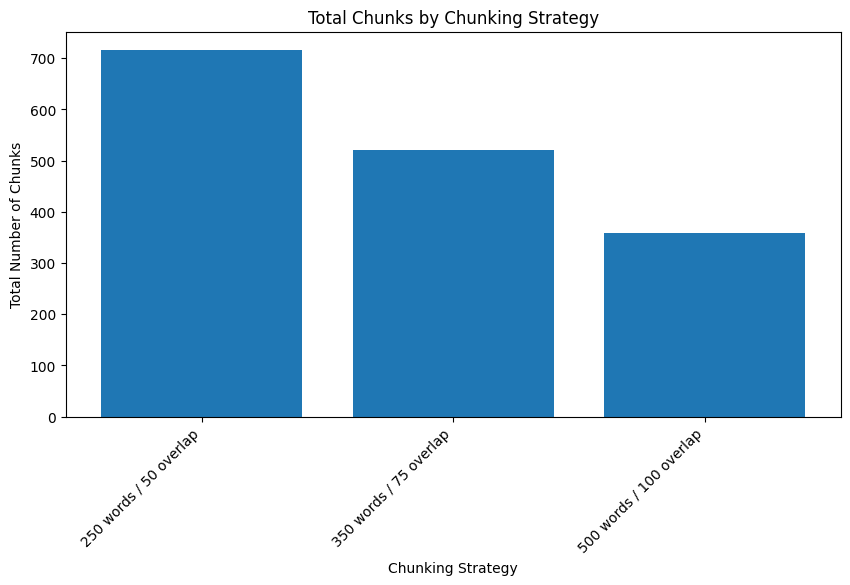

In [14]:
# Create a bar chart comparing total chunks by strategy
plt.figure(figsize=(10, 5))

# Plot total chunks
plt.bar(
    chunking_summary["strategy"],
    chunking_summary["total_chunks"]
)

# Add chart title and labels
plt.title("Total Chunks by Chunking Strategy")
plt.xlabel("Chunking Strategy")
plt.ylabel("Total Number of Chunks")

# Rotate labels for readability
plt.xticks(rotation=45, ha="right")

# Display the chart
plt.show()

In [15]:
# Set final chunking parameters
FINAL_CHUNK_SIZE = 350
FINAL_CHUNK_OVERLAP = 75

# Create an empty list for final chunk records
final_chunk_records = []

# Loop through each SEC section
for _, row in rag_sections_df.iterrows():

    # Create chunks for this section
    chunks = create_word_chunks(
        text=row["text"],
        chunk_size=FINAL_CHUNK_SIZE,
        chunk_overlap=FINAL_CHUNK_OVERLAP
    )

    # Loop through each chunk
    for chunk_index, chunk in enumerate(chunks):

        # Create a unique chunk ID
        chunk_id = f"{row['document_id']}_chunk_{chunk_index:04d}"

        # Create a citation label for later RAG answers
        citation_label = (
            f"{row['ticker']} {row['filing_date']} 10-K, "
            f"{row['section_name']}, chunk {chunk_index}"
        )

        # Store final chunk metadata and text
        final_chunk_records.append({
            "chunk_id": chunk_id,
            "document_id": row["document_id"],
            "ticker": row["ticker"],
            "company_name": row["company_name"],
            "filing_date": row["filing_date"],
            "accession_number": row["accession_number"],
            "filing_url": row["filing_url"],
            "section_name": row["section_name"],
            "source_label": row["source_label"],
            "citation_label": citation_label,
            "chunk_index": chunk_index,
            "chunk_size": FINAL_CHUNK_SIZE,
            "chunk_overlap": FINAL_CHUNK_OVERLAP,
            "start_word": chunk["start_word"],
            "end_word": chunk["end_word"],
            "chunk_word_count": chunk["chunk_word_count"],
            "chunk_character_count": chunk["chunk_character_count"],
            "chunk_text": chunk["chunk_text"]
        })

# Convert final chunk records into a DataFrame
rag_chunks_df = pd.DataFrame(final_chunk_records)

# Preview final RAG chunks
rag_chunks_df.head()

,chunk_id,document_id,ticker,company_name,filing_date,accession_number,filing_url,section_name,source_label,citation_label,chunk_index,chunk_size,chunk_overlap,start_word,end_word,chunk_word_count,chunk_character_count,chunk_text
0,AAPL_2025-10-31_item_1_business_chunk_0000,AAPL_2025-10-31_item_1_business,AAPL,Apple,2025-10-31,0000320193-25-000079,https://www.sec.gov/Archives/edgar/data/320193...,item_1_business,AAPL 2025-10-31 10-K item_1_business,"AAPL 2025-10-31 10-K, item_1_business, chunk 0",0,350,75,0,350,350,2125,Item 1. Business Company Background The Compan...
1,AAPL_2025-10-31_item_1_business_chunk_0001,AAPL_2025-10-31_item_1_business,AAPL,Apple,2025-10-31,0000320193-25-000079,https://www.sec.gov/Archives/edgar/data/320193...,item_1_business,AAPL 2025-10-31 10-K item_1_business,"AAPL 2025-10-31 10-K, item_1_business, chunk 1",1,350,75,275,625,350,2341,Apple Inc. | 2025 Form 10-K | 1 Services Adver...
2,AAPL_2025-10-31_item_1_business_chunk_0002,AAPL_2025-10-31_item_1_business,AAPL,Apple,2025-10-31,0000320193-25-000079,https://www.sec.gov/Archives/edgar/data/320193...,item_1_business,AAPL 2025-10-31 10-K item_1_business,"AAPL 2025-10-31 10-K, item_1_business, chunk 2",2,350,75,550,900,350,2429,"Greater China includes China mainland, Hong Ko..."
3,AAPL_2025-10-31_item_1_business_chunk_0003,AAPL_2025-10-31_item_1_business,AAPL,Apple,2025-10-31,0000320193-25-000079,https://www.sec.gov/Archives/edgar/data/320193...,item_1_business,AAPL 2025-10-31 10-K item_1_business,"AAPL 2025-10-31 10-K, item_1_business, chunk 3",3,350,75,825,1175,350,2563,by imitating the Company’s products and infrin...
4,AAPL_2025-10-31_item_1_business_chunk_0004,AAPL_2025-10-31_item_1_business,AAPL,Apple,2025-10-31,0000320193-25-000079,https://www.sec.gov/Archives/edgar/data/320193...,item_1_business,AAPL 2025-10-31 10-K item_1_business,"AAPL 2025-10-31 10-K, item_1_business, chunk 4",4,350,75,1100,1450,350,2357,provide products and services at little or no ...


In [16]:
# Print total number of chunks
print("Total chunks:", len(rag_chunks_df))

# Print number of unique companies
print("Companies:", rag_chunks_df["ticker"].nunique())

# Print number of unique section types
print("Section types:", rag_chunks_df["section_name"].nunique())

# Count chunks by company and section
chunk_counts = (
    rag_chunks_df
    .groupby(["ticker", "section_name"])
    .size()
    .reset_index(name="num_chunks")
)

# Display chunk counts
chunk_counts

Total chunks: 520
Companies: 5
Section types: 4


,ticker,section_name,num_chunks
0,AAPL,item_1_business,9
1,AAPL,item_1a_risk_factors,36
2,AAPL,item_7_mda,10
3,AAPL,item_7a_market_risk,2
4,AMD,item_1_business,2
5,AMD,item_1a_risk_factors,103
6,AMD,item_7_mda,106
7,AMD,item_7a_market_risk,3
8,MSFT,item_1_business,22
9,MSFT,item_1a_risk_factors,37


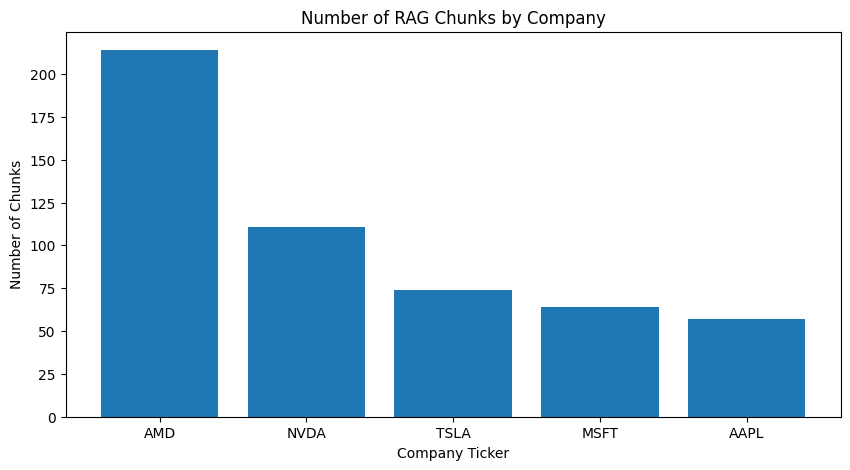

In [17]:
# Count chunks by company
chunks_by_company = (
    rag_chunks_df
    .groupby("ticker")
    .size()
    .reset_index(name="num_chunks")
    .sort_values("num_chunks", ascending=False)
)

# Create a bar chart
plt.figure(figsize=(10, 5))

# Plot chunks by company
plt.bar(
    chunks_by_company["ticker"],
    chunks_by_company["num_chunks"]
)

# Add chart title and labels
plt.title("Number of RAG Chunks by Company")
plt.xlabel("Company Ticker")
plt.ylabel("Number of Chunks")

# Display chart
plt.show()

#### Chart chunks by section

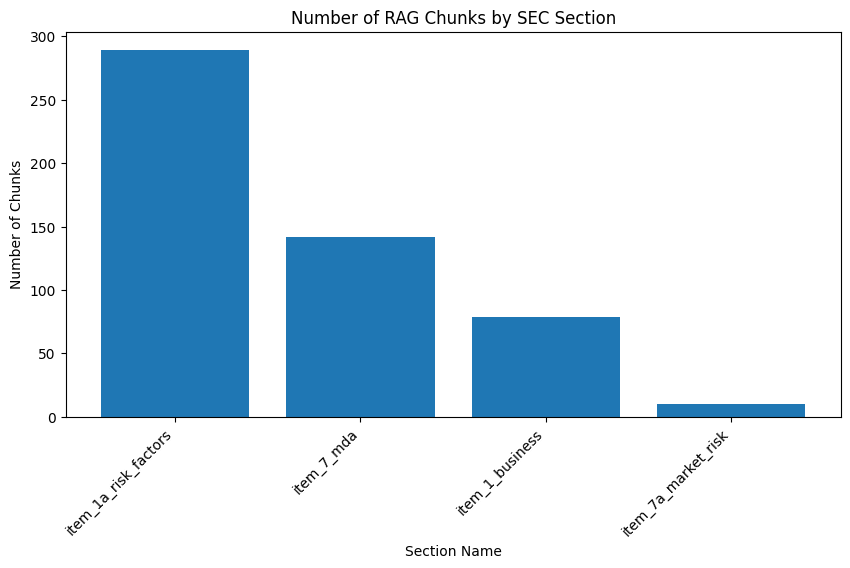

In [18]:
# Count chunks by section
chunks_by_section = (
    rag_chunks_df
    .groupby("section_name")
    .size()
    .reset_index(name="num_chunks")
    .sort_values("num_chunks", ascending=False)
)

# Create a bar chart
plt.figure(figsize=(10, 5))

# Plot chunks by section
plt.bar(
    chunks_by_section["section_name"],
    chunks_by_section["num_chunks"]
)

# Add chart title and labels
plt.title("Number of RAG Chunks by SEC Section")
plt.xlabel("Section Name")
plt.ylabel("Number of Chunks")

# Rotate labels for readability
plt.xticks(rotation=45, ha="right")

# Display chart
plt.show()

In [19]:
# Select the first final chunk
preview_chunk = rag_chunks_df.iloc[0]

# Print chunk metadata
print("Chunk ID:", preview_chunk["chunk_id"])
print("Company:", preview_chunk["ticker"])
print("Section:", preview_chunk["section_name"])
print("Citation:", preview_chunk["citation_label"])
print("Words:", preview_chunk["chunk_word_count"])
print("Filing URL:", preview_chunk["filing_url"])

# Preview chunk text
print(preview_chunk["chunk_text"][:2000])

Chunk ID: AAPL_2025-10-31_item_1_business_chunk_0000
Company: AAPL
Section: item_1_business
Citation: AAPL 2025-10-31 10-K, item_1_business, chunk 0
Words: 350
Filing URL: https://www.sec.gov/Archives/edgar/data/320193/000032019325000079/aapl-20250927.htm
Item 1. Business Company Background The Company designs, manufactures and markets smartphones, personal computers, tablets, wearables and accessories, and sells a variety of related services. The Company’s fiscal year is the 52- or 53-week period that ends on the last Saturday of September. Products iPhone iPhone ® is the Company’s line of smartphones based on its iOS operating system. The iPhone line includes iPhone 17 Pro, iPhone Air™, iPhone 17, iPhone 16 and iPhone 16e. Mac Mac ® is the Company’s line of personal computers based on its macOS ® operating system. The Mac line includes laptops MacBook Air ® and MacBook Pro ® , as well as desktops iMac ® , Mac mini ® , Mac Studio ® and Mac Pro ® . iPad iPad ® is the Company’s line of 

In [20]:
# Set output path for final RAG chunks
rag_chunks_file = PROCESSED_DIR / "sec_10k_rag_chunks.csv"

# Save final RAG chunks to CSV
rag_chunks_df.to_csv(rag_chunks_file, index=False)

# Confirm the file was saved
print("Saved final RAG chunks to:", rag_chunks_file)

Saved final RAG chunks to: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\processed\sec_10k_rag_chunks.csv


In [21]:
# Set output paths for experiment results
chunking_experiments_file = PROCESSED_DIR / "sec_10k_chunking_experiments.csv"
chunking_summary_file = PROCESSED_DIR / "sec_10k_chunking_summary.csv"

# Save detailed experiment results
chunking_experiments_df.to_csv(chunking_experiments_file, index=False)

# Save summary results
chunking_summary.to_csv(chunking_summary_file, index=False)

# Confirm files were saved
print("Saved chunking experiments to:", chunking_experiments_file)
print("Saved chunking summary to:", chunking_summary_file)

Saved chunking experiments to: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\processed\sec_10k_chunking_experiments.csv
Saved chunking summary to: c:\Users\tevin\OneDrive\Desktop\LLM-And-Generative-AI\rag\RiskRadar-AI\data\processed\sec_10k_chunking_summary.csv


In [22]:
# Create final checkpoint table
chunking_checkpoint = pd.DataFrame({
    "output": [
        "Final RAG chunks",
        "Chunking experiments",
        "Chunking summary",
        "Chunk output folder"
    ],
    "path": [
        str(rag_chunks_file),
        str(chunking_experiments_file),
        str(chunking_summary_file),
        str(CHUNK_DIR)
    ],
    "exists": [
        rag_chunks_file.exists(),
        chunking_experiments_file.exists(),
        chunking_summary_file.exists(),
        CHUNK_DIR.exists()
    ]
})

# Display checkpoint table
chunking_checkpoint

,output,path,exists
0,Final RAG chunks,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,True
1,Chunking experiments,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,True
2,Chunking summary,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,True
3,Chunk output folder,c:\Users\tevin\OneDrive\Desktop\LLM-And-Genera...,True


In [23]:
# Validate that the final RAG chunk dataset is ready for embeddings

# Check that the final chunk file exists
print("Chunk file exists:", rag_chunks_file.exists())

# Check the shape of the final chunk dataset
print("Rows and columns:", rag_chunks_df.shape)

# Check for missing chunk text
missing_chunk_text = rag_chunks_df["chunk_text"].isna().sum()
print("Missing chunk text:", missing_chunk_text)

# Check for empty chunk text
empty_chunk_text = (rag_chunks_df["chunk_text"].str.strip() == "").sum()
print("Empty chunk text:", empty_chunk_text)

# Check for duplicate chunk IDs
duplicate_chunk_ids = rag_chunks_df["chunk_id"].duplicated().sum()
print("Duplicate chunk IDs:", duplicate_chunk_ids)

# Check that citation metadata exists
citation_columns = [
    "chunk_id",
    "ticker",
    "company_name",
    "filing_date",
    "section_name",
    "citation_label",
    "filing_url",
    "chunk_text"
]

# Display citation-ready chunk preview
rag_chunks_df[citation_columns].head()

Chunk file exists: True
Rows and columns: (520, 18)
Missing chunk text: 0
Empty chunk text: 0
Duplicate chunk IDs: 0


,chunk_id,ticker,company_name,filing_date,section_name,citation_label,filing_url,chunk_text
0,AAPL_2025-10-31_item_1_business_chunk_0000,AAPL,Apple,2025-10-31,item_1_business,"AAPL 2025-10-31 10-K, item_1_business, chunk 0",https://www.sec.gov/Archives/edgar/data/320193...,Item 1. Business Company Background The Compan...
1,AAPL_2025-10-31_item_1_business_chunk_0001,AAPL,Apple,2025-10-31,item_1_business,"AAPL 2025-10-31 10-K, item_1_business, chunk 1",https://www.sec.gov/Archives/edgar/data/320193...,Apple Inc. | 2025 Form 10-K | 1 Services Adver...
2,AAPL_2025-10-31_item_1_business_chunk_0002,AAPL,Apple,2025-10-31,item_1_business,"AAPL 2025-10-31 10-K, item_1_business, chunk 2",https://www.sec.gov/Archives/edgar/data/320193...,"Greater China includes China mainland, Hong Ko..."
3,AAPL_2025-10-31_item_1_business_chunk_0003,AAPL,Apple,2025-10-31,item_1_business,"AAPL 2025-10-31 10-K, item_1_business, chunk 3",https://www.sec.gov/Archives/edgar/data/320193...,by imitating the Company’s products and infrin...
4,AAPL_2025-10-31_item_1_business_chunk_0004,AAPL,Apple,2025-10-31,item_1_business,"AAPL 2025-10-31 10-K, item_1_business, chunk 4",https://www.sec.gov/Archives/edgar/data/320193...,provide products and services at little or no ...


## Chunking Conclusion

This notebook converted SEC filing sections into RAG-ready chunks.

The project now has:

```text
SEC sections
→ word-based chunks
→ overlap strategy
→ chunk metadata
→ citation labels
→ final RAG chunk dataset
```

The final chunking strategy is:

```text
350 words per chunk
75 words overlap
```

This creates chunks that are large enough to preserve context but small enough for focused retrieval.

The next notebook will create embeddings and store the chunks in a vector database.

```text
RAG chunks
→ embedding model
→ vector database
→ similarity search
→ baseline retrieval
```